### This notebook attempts to conduct event-sequence analysis from a different approach: instead of building sequences from the dcn net work, we will mine the sequences from the original data using the significant conditions identified from the DCN analysis. These sequences are then used as features in ML models for gastric cancer diagnosis.

In [1]:
import pandas as pd
import numpy as np

### 1. Get the unique conditions from the statistically significantly associated pairs identified in the DCN analysis.


In [2]:
import os
print(os.getcwd())

C:\Users\yxing\Documents\projects\Kothari\WHIO\pancreatic_cancer\Event_Sequence_analysis


In [3]:
#load the data file that contains the names of the significantly associated disease pairs
df1=pd.read_excel('pancreatic_sig_pairs_010226.xlsx')

In [4]:
#get all the unique conditions in this file
unique_conditions = pd.unique(df1[['from_disease', 'to_disease']].values.ravel('K')).tolist()

In [5]:
#remove pancreatic_cancer from list
unique_conditions.remove('pancreatic_cancer')

### 2. Pattern mining on the pancreatic_cancer cohort
step 1- get the pancreatic cohort data (same dataset used in previous analysis)

step 2- only keep conditions in above list

step 3-sequence pattern mining, non-continuous subsequences of 2-4 events long; time gap between 2 consective events in a sequence is no greater than 90 days

In [6]:
#load the pancreatic cancer cohort data
df2=pd.read_csv('pancreatic_cancer_dcn_3l_v2.csv', low_memory=False)

In [7]:
#get the subset that contains conditions in the list up 
df_pancreatic=df2[df2['event'].isin(unique_conditions)]

In [8]:
%%time
import pandas as pd
#use prefixspan to ge the sequences
from prefixspan import PrefixSpan
#sort data by date
df_pancreatic['ServiceDate']=pd.to_datetime(df_pancreatic['ServiceDate'], errors='coerce')
df_pancreatic=df_pancreatic.sort_values(['Whio_MemberId','ServiceDate'])


def create_sequences_with_maxgap(df, maxgap_days=90, min_sequence_length=2):
    """
    Create sequences with maxgap constraint
    Assumes: df already contains only pre-diagnosis events, sorted by date
    """
    all_sequences = []
    
    for patient_id in df['Whio_MemberId'].unique():
        patient_df = df[df['Whio_MemberId'] == patient_id].sort_values('ServiceDate')
        
        if len(patient_df) == 0:
            continue
        
        # Build sequences respecting maxgap constraint
        current_sequence = [patient_df.iloc[0]['event']]
        prev_date = patient_df.iloc[0]['ServiceDate']
        
        for i in range(1, len(patient_df)):
            current_date = patient_df.iloc[i]['ServiceDate']
            gap = (current_date - prev_date).days
            
            if gap <= maxgap_days:
                current_sequence.append(patient_df.iloc[i]['event'])
            else:
                # Gap too large - save current and start new
                if len(current_sequence) >= min_sequence_length:
                    all_sequences.append(current_sequence)
                current_sequence = [patient_df.iloc[i]['event']]
            
            prev_date = current_date
        
        # Save final sequence
        if len(current_sequence) >= min_sequence_length:
            all_sequences.append(current_sequence)
    
    return all_sequences

# Without maxgap (baseline)
sequences_no_gap = df_pancreatic.groupby('Whio_MemberId')['event'].apply(list).tolist()
print(f"Without maxgap: {len(sequences_no_gap)} sequences")

# With maxgap
sequences_90d = create_sequences_with_maxgap(df_pancreatic, maxgap_days=90)
print(f"With maxgap=90: {len(sequences_90d)} sequences")

# Run PrefixSpan
total_sequences=len(sequences_90d)
min_support_percent=0.02 # at least 2 percent of all cases 
minsup = int(np.ceil(total_sequences * min_support_percent))
ps = PrefixSpan(sequences_90d)
patterns = ps.frequent(minsup=minsup)

## select patterns of lenth 2-4,with only unique items
patterns_filtered = [
    (freq, pattern)
    for freq, pattern in patterns
    if 2 <= len(pattern) <= 4 and len(pattern) == len(set(pattern))
] 
# Convert to a dataframe
pancreatic_freq_df_90d = pd.DataFrame(patterns_filtered, columns=['frequency', 'sequence'])
pancreatic_freq_df_90d['frequency_pct'] = pancreatic_freq_df_90d['frequency'] / len(sequences_90d)
pancreatic_freq_df_90d.sort_values('frequency', ascending=False, inplace=True)


<timed exec>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Without maxgap: 4990 sequences
With maxgap=90: 14805 sequences
CPU times: total: 40.9 s
Wall time: 41 s


In [9]:
pancreatic_freq_df_90d

,frequency,sequence,frequency_pct
56,1107,"[M25, M79]",0.074772
60,969,"[M25, M54]",0.065451
20,901,"[M54, M79]",0.060858
72,865,"[M79, M25]",0.058426
54,814,"[G89, M54]",0.054981
...,...,...,...
67,304,"[M25, M48]",0.020534
50,299,"[M51, M79]",0.020196
47,298,"[K86, K83]",0.020128
57,298,"[M25, K21]",0.020128


In [10]:
#clean up the sequences by removing hidden white spaces, single and double quotes
def clean_seq(seq):
    cleaned = []
    for x in seq:
        if not isinstance(x, str):
            continue
        x = x.strip()           # remove whitespace
        x = x.strip("'")        # remove single quotes
        x = x.strip('"')        # remove double quotes if any
        if x != "":
            cleaned.append(x)
    return "->".join(cleaned)

pancreatic_freq_df_90d["sequence"] = pancreatic_freq_df_90d["sequence"].apply(clean_seq)

In [11]:
pancreatic_freq_df_90d

,frequency,sequence,frequency_pct
56,1107,M25->M79,0.074772
60,969,M25->M54,0.065451
20,901,M54->M79,0.060858
72,865,M79->M25,0.058426
54,814,G89->M54,0.054981
...,...,...,...
67,304,M25->M48,0.020534
50,299,M51->M79,0.020196
47,298,K86->K83,0.020128
57,298,M25->K21,0.020128


There are 92 unique sequences in the pancreatic cohort that meet the requirement (2-4 events, maxgap=90d). 

### 3. Check the sequence frequencies in the non-pancreatic cohort

In [12]:
#load the non-pancreatic cancer cohort data
df3=pd.read_csv('non_pancreatic_cancer_dcn_3l_v2.csv')

In [13]:
%%time
#get the subset that contains conditions in the list up 
df_non_pancreatic=df3[df3['event'].isin(unique_conditions)]

#sort data by date
df_non_pancreatic['ServiceDate']=pd.to_datetime(df_non_pancreatic['ServiceDate'], errors='coerce')
df_non_pancreatic=df_non_pancreatic.sort_values(['Whio_MemberId','ServiceDate'])
# With maxgap
sequences_90d = create_sequences_with_maxgap(df_non_pancreatic, maxgap_days=90)
print(f"With maxgap=90: {len(sequences_90d)} sequences")

# Run PrefixSpan
total_sequences=len(sequences_90d)
min_support_percent=0.02
minsup = int(np.ceil(total_sequences * min_support_percent))
ps = PrefixSpan(sequences_90d)
patterns = ps.frequent(minsup=minsup)

patterns_filtered = [
    (freq, pattern)
    for freq, pattern in patterns
    if 2 <= len(pattern) <= 4 and len(pattern) == len(set(pattern))
] # patterns of lenth 2-4,with onlu unique items
# Convert to a dataframe
non_pancreatic_freq_df_90d = pd.DataFrame(patterns_filtered, columns=['frequency', 'sequence'])
non_pancreatic_freq_df_90d['frequency_pct'] = non_pancreatic_freq_df_90d['frequency'] / len(sequences_90d)
non_pancreatic_freq_df_90d.sort_values('frequency', ascending=False, inplace=True)


<timed exec>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


With maxgap=90: 46140 sequences
CPU times: total: 3min 30s
Wall time: 3min 31s


In [14]:
#clean up the sequences
non_pancreatic_freq_df_90d["sequence"] = non_pancreatic_freq_df_90d["sequence"].apply(clean_seq)
non_pancreatic_freq_df_90d

,frequency,sequence,frequency_pct
94,4260,J90->J98,0.092328
29,2801,E87->J90,0.060707
92,2723,J90->J96,0.059016
122,2254,J18->J90,0.048851
35,2245,E87->J98,0.048656
...,...,...,...
38,928,E87->I48,0.020113
140,927,J96->I50,0.020091
45,926,M79->E87,0.020069
89,923,J90->G47,0.020004


There are 126 unique sequences that meet the requirement (2-4 events, maxgap=90d).

### 4. Find the sequences which has frequencies that are significantly different between the two cohorts

In [15]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest


# Rename for merge safety
pancreatic_freq_df_90d.columns = ["pancreatic_freq","sequence","pancreatic_freq_pct"]
non_pancreatic_freq_df_90d.columns = ["non_pancreatic_freq","sequence","non_pancreatic_freq_pct"]

# Combine to keep unique sequences
freq_df = pd.merge(pancreatic_freq_df_90d,non_pancreatic_freq_df_90d, on="sequence", how="outer")
n1=2446
n2=4403

# Proportion values
freq_df['pancreatic_prop'] = freq_df['pancreatic_freq_pct']
freq_df['non_pancreatic_prop'] = freq_df['non_pancreatic_freq_pct']

# Run z-test per sequence
p_values = []
z_scores = []

for c1, c2 in zip(freq_df['pancreatic_freq'], freq_df['non_pancreatic_freq']):
    z, p = proportions_ztest([c1, c2], [n1, n2])
    p_values.append(p)
    z_scores.append(z)

freq_df['z_score'] = z_scores
freq_df['p_value'] = p_values

# adjust p-value if needed (FDR / Bonferroni)
freq_df['p_adj'] = freq_df['p_value'] * len(freq_df)  # Bonferroni

# Flag significant sequences
freq_df['significant'] = freq_df['p_adj'] < 0.05

# output only significant different sequences
df_sig = freq_df[freq_df['significant']].sort_values('p_adj')


In [16]:
positive_seq=df_sig[df_sig['pancreatic_freq_pct']>df_sig['non_pancreatic_freq_pct']]
positive_seq['sequence'].unique()                                                       

array(['M25->M54', 'M25->M79', 'M79->M25', 'M79->E87', 'M54->M79',
       'I12->N18', 'G89->M54', 'G89->M25'], dtype=object)

In [17]:
df_sig

,pancreatic_freq,sequence,pancreatic_freq_pct,non_pancreatic_freq,non_pancreatic_freq_pct,pancreatic_prop,non_pancreatic_prop,z_score,p_value,p_adj,significant
171,969.0,M25->M54,0.065451,1052.0,0.022800,0.065451,0.022800,13.670424,1.525042e-42,3.355091e-40,True
42,305.0,E87->M79,0.020601,1113.0,0.024122,0.020601,0.024122,-12.535722,4.760069e-36,1.047215e-33,True
174,1107.0,M25->M79,0.074772,1372.0,0.029736,0.074772,0.029736,11.632246,2.825622e-31,6.216368e-29,True
204,865.0,M79->M25,0.058426,988.0,0.021413,0.058426,0.021413,11.536785,8.608309e-31,1.893828e-28,True
198,313.0,M79->E87,0.021142,926.0,0.020069,0.021142,0.020069,-8.482962,2.195321e-17,4.829707e-15,True
195,901.0,M54->M79,0.060858,1197.0,0.025943,0.060858,0.025943,8.301031,1.032119e-16,2.270661e-14,True
59,437.0,I12->N18,0.029517,1144.0,0.024794,0.029517,0.024794,-7.638178,2.203171e-14,4.846977e-12,True
56,814.0,G89->M54,0.054981,1099.0,0.023819,0.054981,0.023819,7.352240,1.949125e-13,4.288075e-11,True
54,778.0,G89->M25,0.052550,1103.0,0.023906,0.052550,0.023906,6.002278,1.945679e-09,4.280493e-07,True


There are 9 sequences with frequencies that are significantly different between the two cohorts.

In [18]:
filtered_seqs=df_sig['sequence']
filtered_seqs.to_csv('pattern_mining_sig_seqs_012726.csv')

### 5. Create columns with sequence names, if a patient has that sequence, it will be labeled as 1, also creating a columns of the starting date of the sequence ; if that patient doesn't have that sequence, it's labeled as 0, the starting date is set to None

#### 5.1. Prepare the pancreatic cancer cohort

In [19]:
df=df2[['Whio_MemberId', 'event', 'ServiceDate']]
df['ServiceDate']=pd.to_datetime(df['ServiceDate'])
sequences = df_sig['sequence'].unique()
# Helper function: check subsequence and return start and end dates if found
def subsequence_start(events, dates, subseq):
    subseq = subseq.split("->")  # e.g. "a-b" -> ["a", "b"]
    m = len(subseq)
    i = 0
    start_date = None
    end_date = None

    for j, ev in enumerate(events):
        if ev == subseq[i]:
            if i == 0:
                start_date = dates[j].date()  # first match
            i += 1
            if i == m:
                end_date = dates[j].date()   # last match
                return 1, start_date, end_date

    return 0, None, None

# Aggregate events & dates per ID
df_sorted = df.sort_values(["Whio_MemberId","ServiceDate"])
agg = df_sorted.groupby("Whio_MemberId").agg({"event": list, "ServiceDate": list})

# Result dataframe
result = pd.DataFrame(index=agg.index)
## Add last event date per ID
result["last_event_date"] = agg["ServiceDate"].apply(lambda d: d[-1].date())
# Add columns for each sequence
for seq in sequences:
    result[seq] = 0
    result[seq + "_start"] = None
    
    for idx, row in agg.iterrows():
        flag, start_date,end_date = subsequence_start(row["event"], row["ServiceDate"], seq)
        result.at[idx, seq] = flag
        result.at[idx, seq + "_start"] = start_date
        result.at[idx, seq + "_end"] = end_date


C:\Users\yxing\AppData\Local\Temp\ipykernel_20344\3540659512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ServiceDate']=pd.to_datetime(df['ServiceDate'])


In [20]:
pancreatic_seq_df=result.copy()
#get demographics date
df2_demographics=df2.drop(['event', 'ServiceDate','Encounter_type'],axis=1)
df2_demographics=df2_demographics.drop_duplicates()
#keep the oldest age
idx = df2_demographics.groupby("Whio_MemberId")["Age_dx"].idxmax()
df2_dmg =df2_demographics.loc[idx].reset_index(drop=True)
#merge with age_dx, sex columns in df2
pancreatic_final=pd.merge(df2_dmg,pancreatic_seq_df,on='Whio_MemberId',how='left')
#add a column called pancreatic cancer
pancreatic_final['pancreatic_cancer_dx']=1

In [21]:
pancreatic_final.head()

,Whio_MemberId,Age_dx,Sex,last_event_date,M25->M54,M25->M54_start,M25->M54_end,E87->M79,E87->M79_start,E87->M79_end,...,I12->N18,I12->N18_start,I12->N18_end,G89->M54,G89->M54_start,G89->M54_end,G89->M25,G89->M25_start,G89->M25_end,pancreatic_cancer_dx
0,WHIO1000492,73.0,M,2024-03-09,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
1,WHIO1001631,77.0,F,2023-09-11,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
2,WHIO1001802,56.0,F,2021-03-08,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
3,WHIO1001965,62.0,M,2021-01-25,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
4,WHIO1002083,64.0,F,2019-07-23,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1


#### 5.2. Prepare the non-pancreatic cancer cohort

In [22]:
df=df3[['Whio_MemberId', 'event', 'ServiceDate']]
df['ServiceDate']=pd.to_datetime(df['ServiceDate'])

# Aggregate events & dates per ID
df_sorted = df.sort_values(["Whio_MemberId","ServiceDate"])
agg = df_sorted.groupby("Whio_MemberId").agg({"event": list, "ServiceDate": list})

# Result dataframe
result = pd.DataFrame(index=agg.index)
## Add last event date per ID
result["last_event_date"] = agg["ServiceDate"].apply(lambda d: d[-1].date())
# Add columns for each sequence
for seq in sequences:
    result[seq] = 0
    result[seq + "_start"] = None
    
    for idx, row in agg.iterrows():
        flag, start_date,end_date = subsequence_start(row["event"], row["ServiceDate"], seq)
        result.at[idx, seq] = flag
        result.at[idx, seq + "_start"] = start_date
        result.at[idx, seq + "_end"] = end_date
non_pancreatic_seq_df=result.copy()
#get demographics data
df3_demographics=df3.drop(['event', 'ServiceDate','Encounter_type'],axis=1)
df3_demographics=df3_demographics.drop_duplicates()
#merge with age_dx, sex columns in df2
non_pancreatic_final=pd.merge(df3_demographics,non_pancreatic_seq_df,on='Whio_MemberId',how='left')
#add a column 'pancreatic_cancer_dx'
non_pancreatic_final['pancreatic_cancer_dx']=0

C:\Users\yxing\AppData\Local\Temp\ipykernel_20344\3331390273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ServiceDate']=pd.to_datetime(df['ServiceDate'])


In [23]:
non_pancreatic_final.head()

,Whio_MemberId,Age_last_dx,Sex,last_event_date,M25->M54,M25->M54_start,M25->M54_end,E87->M79,E87->M79_start,E87->M79_end,...,I12->N18,I12->N18_start,I12->N18_end,G89->M54,G89->M54_start,G89->M54_end,G89->M25,G89->M25_start,G89->M25_end,pancreatic_cancer_dx
0,WHIO1000790,61.0,M,2024-05-30,1,2018-08-03,2022-09-14,1,2021-03-19,2021-04-02,...,0,None,None,0,None,None,0,None,None,0
1,WHIO1001036,75.0,F,2017-08-08,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,0
2,WHIO1001105,52.0,F,2023-06-15,1,2017-03-31,2017-06-13,0,None,None,...,0,None,None,0,None,None,0,None,None,0
3,WHIO1002015,74.0,M,2022-08-05,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,0
4,WHIO1002226,33.0,F,2025-01-31,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,0


#### 5.3. Combine the two dataset row-wise

In [24]:
#rename age for both columns to be consistent
pancreatic_final=pancreatic_final.rename(columns={'Age_dx':'Age'})
non_pancreatic_final=non_pancreatic_final.rename(columns={'Age_last_dx':'Age'})
#merge the two datasets
pancreatic_seq_analysis=pd.concat([pancreatic_final,non_pancreatic_final],ignore_index=True)

In [25]:
pancreatic_seq_analysis.shape

(16989, 32)

In [26]:
pancreatic_seq_analysis.to_csv('pattern_mining_pancreatic_seq_analysis_data_012726.csv')

### 6. Analysis

In [27]:
df_analysis=pancreatic_seq_analysis.copy()

In [28]:
#drop all the sequence starting/ending dates columns, they are not needed for the modeling
df_analysis=df_analysis.loc[:,~df_analysis.columns.str.endswith(('_start','_end'))]

In [29]:
#convert sex to 1-M and 0-F
df_analysis['Sex']=df_analysis['Sex'].map({"M":1,"F":0})

In [30]:
df_analysis.shape

(16989, 14)

In [31]:
df_analysis['pancreatic_cancer_dx'].value_counts()

pancreatic_cancer_dx
0    11319
1     5670
Name: count, dtype: int64

In [32]:
df_analysis.sample(5)

,Whio_MemberId,Age,Sex,last_event_date,M25->M54,E87->M79,M25->M79,M79->M25,M79->E87,M54->M79,I12->N18,G89->M54,G89->M25,pancreatic_cancer_dx
13959,WHIO4320672,41.0,1,2025-05-21,0,0,1,0,1,0,0,0,0,0
10069,WHIO2779731,65.0,1,2023-11-07,1,0,1,0,1,0,0,1,0,0
13779,WHIO4248517,60.0,0,2021-09-26,1,1,1,0,0,0,0,1,1,0
10602,WHIO2986089,70.0,0,2024-12-13,1,0,1,0,1,0,0,1,0,0
15758,WHIO503054472,66.0,0,2022-03-03,0,0,0,0,0,0,0,0,0,0


#### 6.1 Univariate logistic regression

In [33]:
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
import statsmodels.api as sm
# Your original code works fine for significance screening
df_lr = df_analysis.copy()
y_col = "pancreatic_cancer_dx"
X_cols = [c for c in df_lr.columns if c not in ('pancreatic_cancer_dx','Age','Sex')]
results = []

for col in X_cols:
    X = df_lr[[col]+['Age','Sex']].copy()
    X = sm.add_constant(X)
    y = df_lr[y_col]
    try:
        model = sm.Logit(y, X).fit(disp=0)

        # Focus on what you need: variable name and p-value
        summary = {
            "variable": col,
            "p_value": model.pvalues[col],
            "coef": model.params[col]
        }
        results.append(summary)
    except:
        print(f"Could not fit model for {col}")

univariate_results = pd.DataFrame(results)



Could not fit model for Whio_MemberId
Could not fit model for last_event_date


In [34]:
# Find significant variables (p < 0.05)
significant_vars = univariate_results[univariate_results['p_value'] < 0.05]
print(f"Found {len(significant_vars)} significant variables")

Found 8 significant variables


In [35]:
#check how many are risk sequences
sig_postive=set(significant_vars['variable'].unique()) & set (positive_seq['sequence'].unique())
sig_postive

{'G89->M54',
 'I12->N18',
 'M25->M54',
 'M25->M79',
 'M54->M79',
 'M79->E87',
 'M79->M25'}

In [36]:
significant_vars.to_csv("pattern_mining_sig_univariate_012626.csv")

In [37]:
print(f'There are {len(significant_vars)} sequences that are statistically significant between the two groups.')

There are 8 sequences that are statistically significant between the two groups.


#### 6.2. Predictive modeling

In [38]:
#only use sequences that are statistically significant in the univariate analysis
seq_var=significant_vars['variable'].unique()
cols_to_select = ['Age', 'Sex','pancreatic_cancer_dx'] + [col for col in seq_var if col in df_lr.columns]

In [39]:
df_pred=df_lr[cols_to_select]

In [40]:
X=df_pred.drop(['pancreatic_cancer_dx'],axis=1)
y=df_pred['pancreatic_cancer_dx']

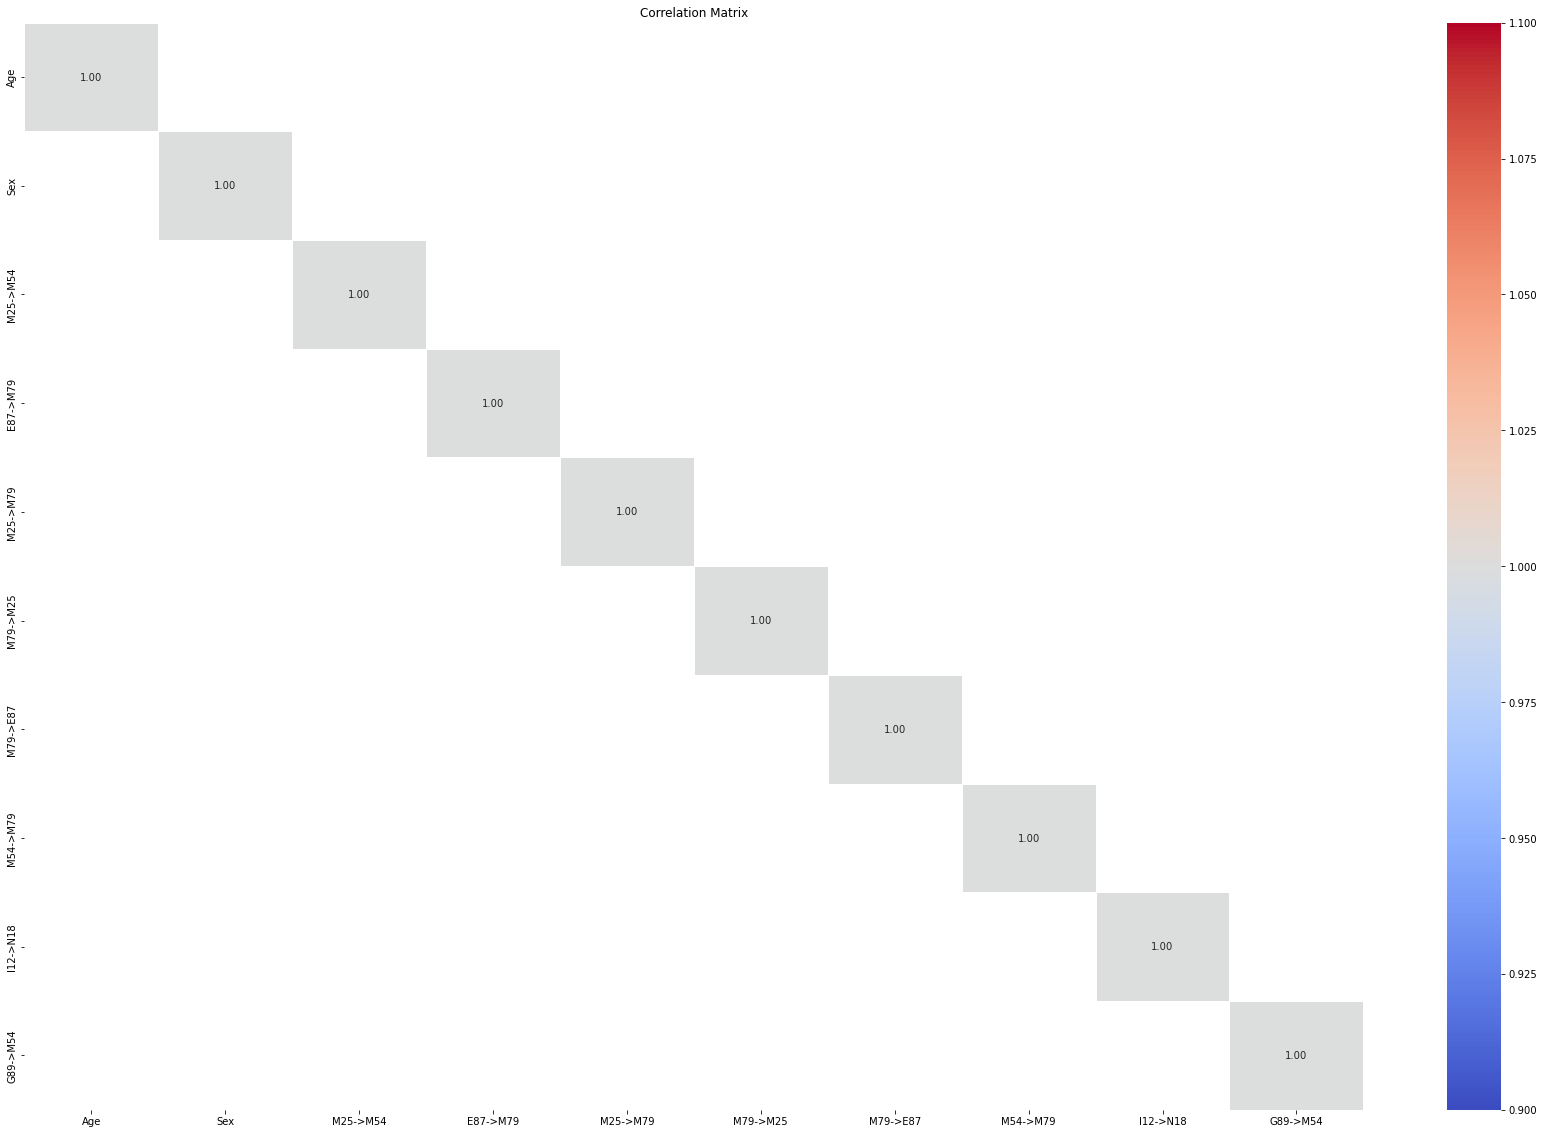

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
# check variable colinearity
correlation_matrix = X.corr()
filtered_correlation = correlation_matrix.where(abs(correlation_matrix) > 0.5)
plt.figure(figsize=(30,20))
sns.heatmap(filtered_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [42]:
from sklearn.model_selection import train_test_split,cross_val_score

# we will do a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### 6.3.1. Logistic regression

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.68      0.91      0.78      3377
           1       0.49      0.18      0.26      1720

    accuracy                           0.66      5097
   macro avg       0.59      0.54      0.52      5097
weighted avg       0.62      0.66      0.60      5097



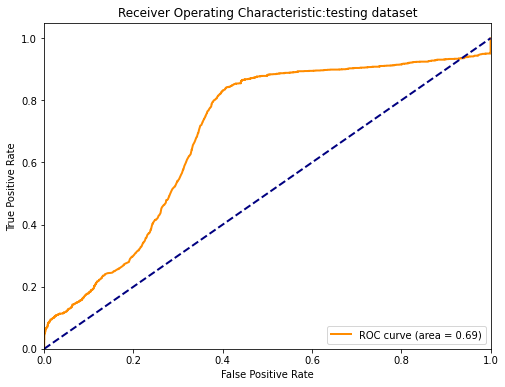

Confusion Matrix:
 [[3058  319]
 [1417  303]]


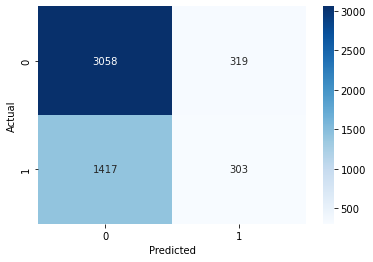

In [43]:
###Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,f1_score
LR_model = LogisticRegression(max_iter=500)
LR_model.fit(X_train, y_train) # we will train the model on the entire dataset
y_pred = LR_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

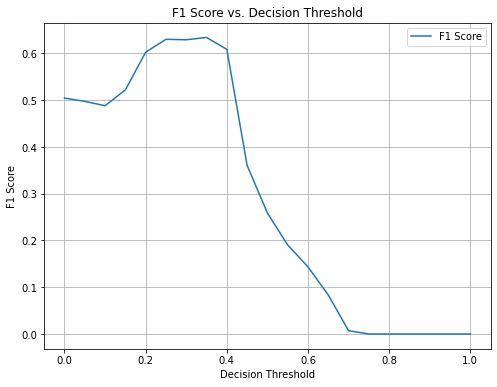

array([0.35])

In [44]:
#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)

# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

In [45]:
y_pred_optimal = (y_probs >= 0.5).astype(int)
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.68      0.91      0.78      3377
           1       0.49      0.18      0.26      1720

    accuracy                           0.66      5097
   macro avg       0.59      0.54      0.52      5097
weighted avg       0.62      0.66      0.60      5097



Classification Report: Logistic Regression, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.69      0.91      0.79      7942
           1       0.51      0.19      0.28      3950

    accuracy                           0.67     11892
   macro avg       0.60      0.55      0.53     11892
weighted avg       0.63      0.67      0.62     11892



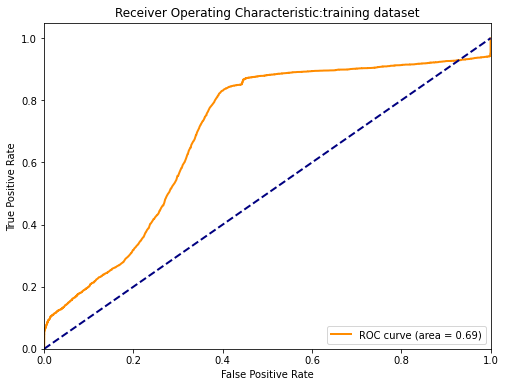

In [46]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = LR_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Logistic Regression, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:training dataset')
plt.legend(loc="lower right")
plt.show()

No overfitting issue for the logistic regression model.

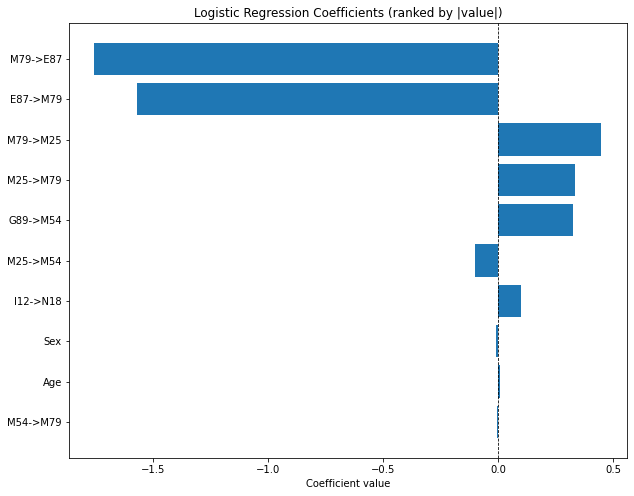

In [47]:
# Get coefficients
coef = LR_model.coef_[0]
features = X.columns

# Put into DataFrame for easy sorting
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": coef,
    "abs_coef": np.abs(coef)
})

# Sort by absolute value
coef_df = coef_df.sort_values("abs_coef", ascending=True)

# Take top 10 by absolute value
top_coef = coef_df.nlargest(10, "abs_coef").sort_values("abs_coef", ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Logistic Regression Coefficients (ranked by |value|)")
plt.xlabel("Coefficient value")
plt.show()

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.68      0.91      0.78      3377
           1       0.49      0.18      0.26      1720

    accuracy                           0.66      5097
   macro avg       0.59      0.54      0.52      5097
weighted avg       0.62      0.66      0.60      5097



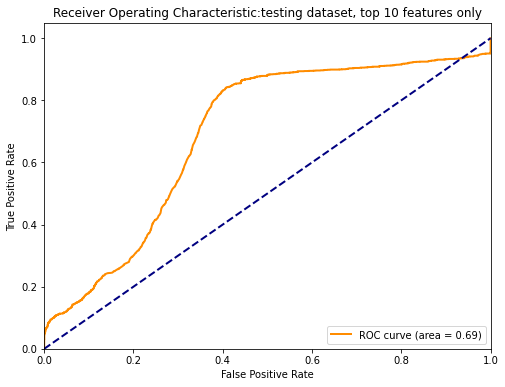

Confusion Matrix:
 [[3058  319]
 [1417  303]]


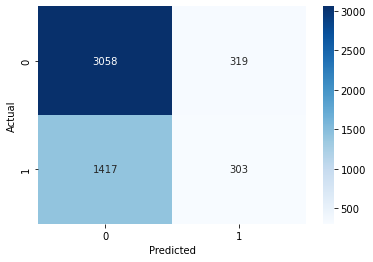

In [48]:
#model with top 10 features only
top_features=top_coef["feature"].tolist()
LR_top = LogisticRegression(max_iter=500)
LR_top.fit(X_train[top_features], y_train) # we will train the model on the entire dataset
y_pred = LR_top.predict(X_test[top_features])
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_top.predict_proba(X_test[top_features])[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:testing dataset, top 10 features only')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 6.3.2. Random forest

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      3377
           1       0.63      0.64      0.63      1720

    accuracy                           0.75      5097
   macro avg       0.72      0.72      0.72      5097
weighted avg       0.75      0.75      0.75      5097



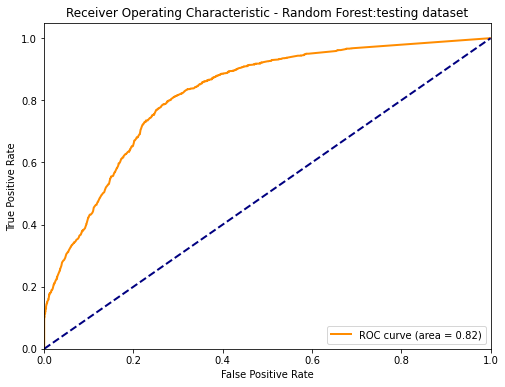

Confusion Matrix:
 [[2735  642]
 [ 627 1093]]


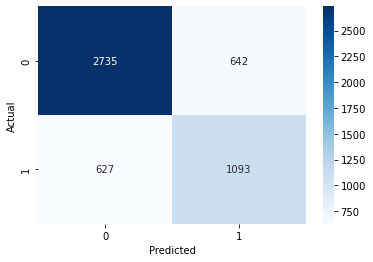

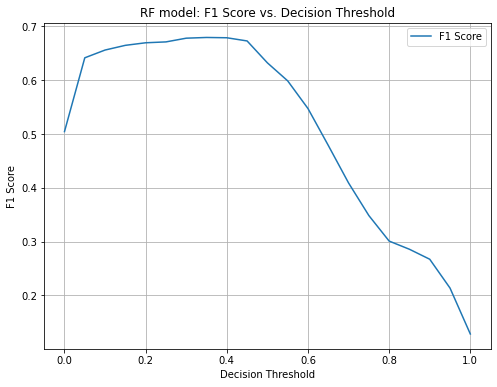

array([0.35])

In [49]:
## Random forest model
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred=rf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
# Predict probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)

# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('RF model: F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

In [50]:
y_pred_optimal = (y_probs >= 0.3).astype(int)
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.88      0.69      0.78      3377
           1       0.58      0.82      0.68      1720

    accuracy                           0.74      5097
   macro avg       0.73      0.76      0.73      5097
weighted avg       0.78      0.74      0.74      5097



Classification Report: Random forest, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      7942
           1       0.73      0.78      0.75      3950

    accuracy                           0.83     11892
   macro avg       0.81      0.82      0.81     11892
weighted avg       0.83      0.83      0.83     11892



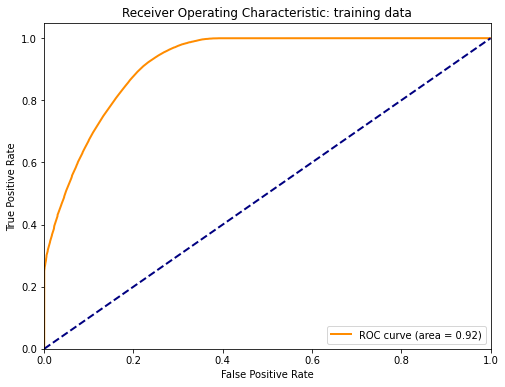

In [51]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = rf_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Random forest, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = rf_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic: training data')
plt.legend(loc="lower right")
plt.show()

Discrepancy between results on training and test dataset suggests overfitting. 

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      3377
           1       0.71      0.78      0.74      1720

    accuracy                           0.82      5097
   macro avg       0.80      0.81      0.80      5097
weighted avg       0.82      0.82      0.82      5097



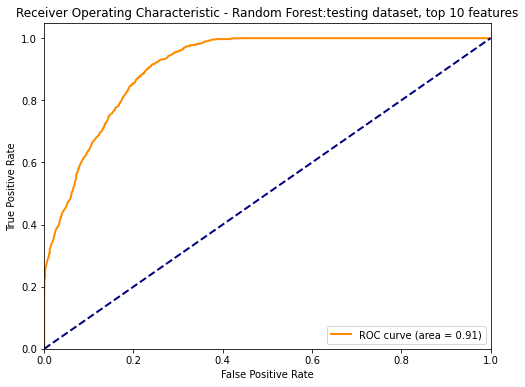

Confusion Matrix:
 [[2831  546]
 [ 381 1339]]


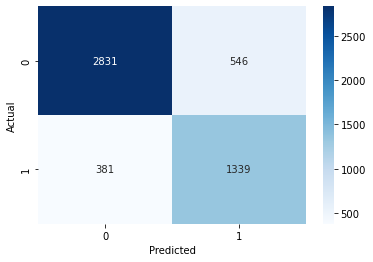

In [52]:
# Get feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(10).index

rf_top_features = top_features.tolist()

# Refit model using only those top features
rf_top = RandomForestClassifier(n_estimators=10, random_state=42)
rf_top.fit(X[rf_top_features], y)

y_pred=rf_top.predict(X_test[rf_top_features])
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
# Predict probabilities
y_probs = rf_top.predict_proba(X_test[rf_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest:testing dataset, top 10 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Fewer features actually improved model performance on the test data, confirming overfitting issue with the full model.

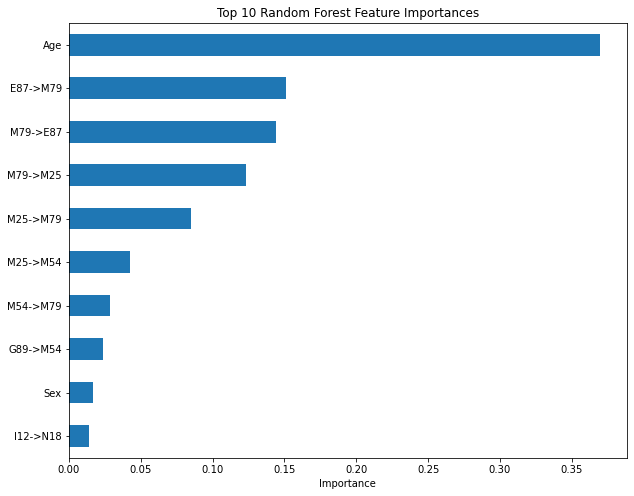

In [53]:
# Get feature importances (by default, "weight")
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Select top 10 features
top_features = importances.nlargest(10)
# Plot horizontal bar chart
plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

Classification Report: Random forest, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      7942
           1       0.70      0.79      0.74      3950

    accuracy                           0.82     11892
   macro avg       0.79      0.81      0.80     11892
weighted avg       0.83      0.82      0.82     11892



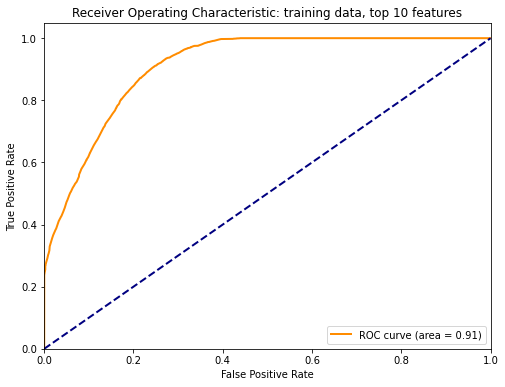

Confusion Matrix:
 [[6608 1334]
 [ 831 3119]]


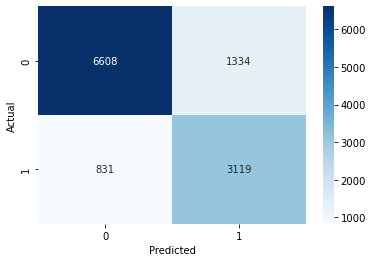

In [54]:
#troubleshooting, find out reason for poor model performance
#evaluate model on the training dataset
y_pred = rf_top.predict(X_train[rf_top_features])
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Random forest, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = rf_top.predict_proba(X_train[rf_top_features])[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic: training data, top 10 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The RF model with only 10 features performs equally well on the training and testing datasets. 

#### 6.3.3 XGBoost

Accuracy: 0.7706494016087895
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      3377
           1       0.66      0.67      0.66      1720

    accuracy                           0.77      5097
   macro avg       0.74      0.75      0.75      5097
weighted avg       0.77      0.77      0.77      5097



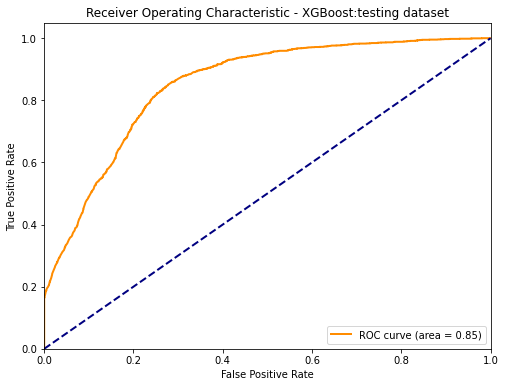

Confusion Matrix:
 [[2769  608]
 [ 561 1159]]


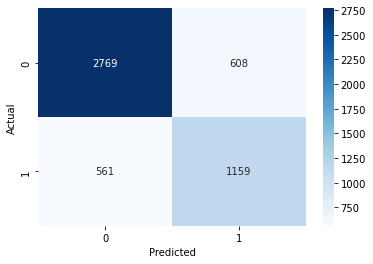

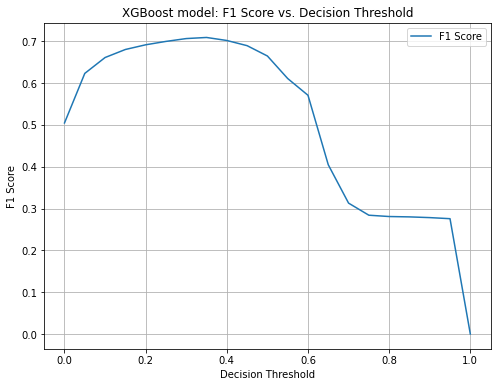

array([0.35])

In [55]:
import xgboost as xgb
# Train XGBoost classifier
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Predict probabilities
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)


# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('XGBoost model: F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

Classification Report: XGBoosting, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      7942
           1       0.68      0.73      0.71      3950

    accuracy                           0.80     11892
   macro avg       0.77      0.78      0.78     11892
weighted avg       0.80      0.80      0.80     11892



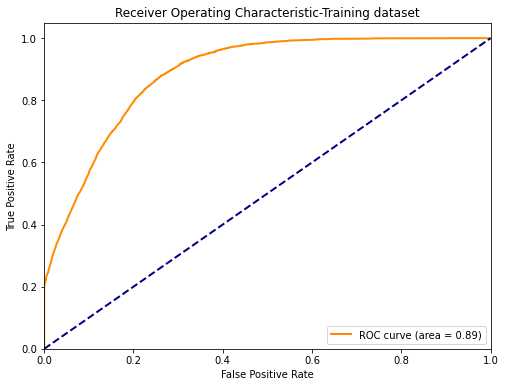

In [56]:
#trouble shooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = xgb_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: XGBoosting, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = xgb_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic-Training dataset')
plt.legend(loc="lower right")
plt.show()

Discrepancy in model performance on the training and testing dataset suggest overfitting of the full model.

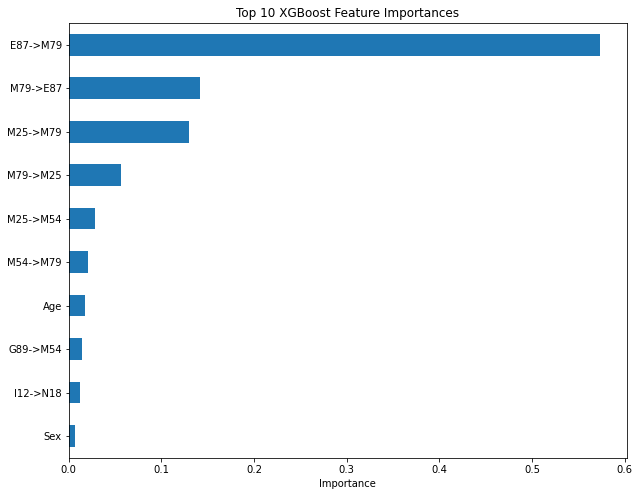

In [57]:
# Get feature importances (by default, "weight")
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(10)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

Accuracy: 0.7706494016087895
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      3377
           1       0.66      0.67      0.66      1720

    accuracy                           0.77      5097
   macro avg       0.74      0.75      0.75      5097
weighted avg       0.77      0.77      0.77      5097



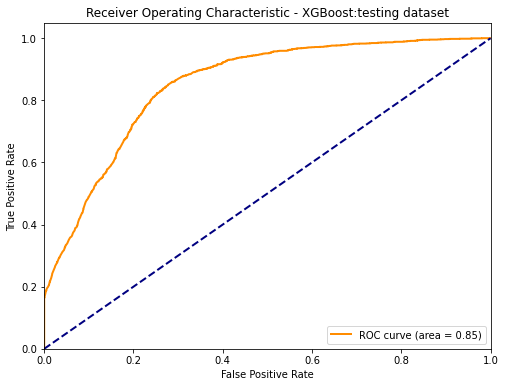

Confusion Matrix:
 [[2769  608]
 [ 561 1159]]


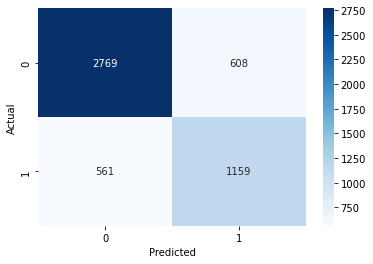

In [58]:
top_10 = importances.nlargest(10).index
xgb_top_features=top_10.tolist()
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train[xgb_top_features], y_train)

y_pred = xgb_model.predict(X_test[xgb_top_features])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_model.predict_proba(X_test[xgb_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

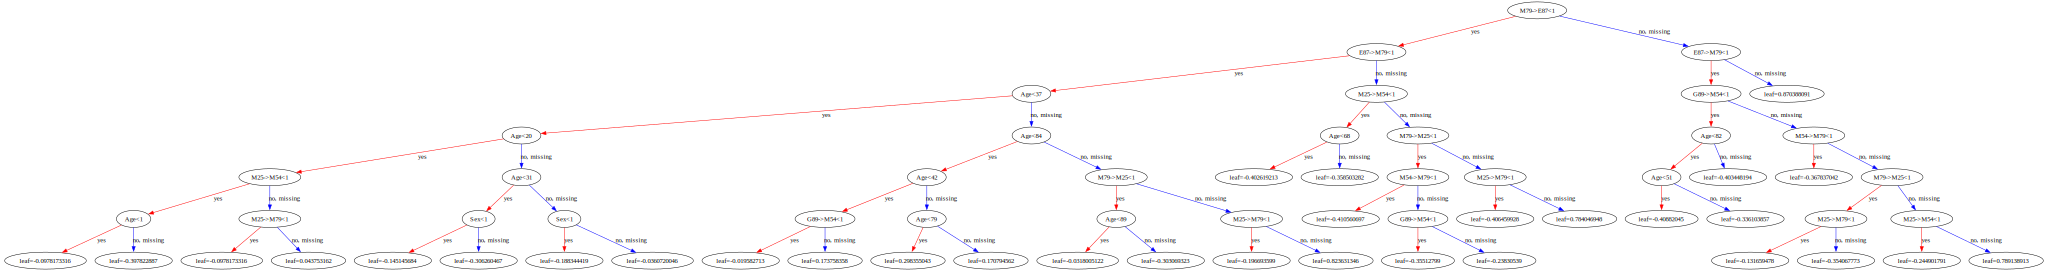

In [59]:
# Plot a specific tree (e.g., the first tree, index 0)
xgb.to_graphviz(xgb_model, num_trees=0, rankdir='TB')

In [60]:
#model optimization

xgb_clf = xgb.XGBClassifier(
    max_depth=5, 
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    early_stopping_rounds=50,
    verbose=True
)


[0]	validation_0-auc:0.77869
[1]	validation_0-auc:0.80161
[2]	validation_0-auc:0.82782
[3]	validation_0-auc:0.84038
[4]	validation_0-auc:0.84100
[5]	validation_0-auc:0.84007
[6]	validation_0-auc:0.83798
[7]	validation_0-auc:0.83792
[8]	validation_0-auc:0.84064
[9]	validation_0-auc:0.84060
[10]	validation_0-auc:0.83923
[11]	validation_0-auc:0.83953
[12]	validation_0-auc:0.84122
[13]	validation_0-auc:0.84254
[14]	validation_0-auc:0.84181
[15]	validation_0-auc:0.84224
[16]	validation_0-auc:0.84277
[17]	validation_0-auc:0.84404
[18]	validation_0-auc:0.84391
[19]	validation_0-auc:0.84343
[20]	validation_0-auc:0.84458
[21]	validation_0-auc:0.84430
[22]	validation_0-auc:0.84392
[23]	validation_0-auc:0.84349
[24]	validation_0-auc:0.84328
[25]	validation_0-auc:0.84313
[26]	validation_0-auc:0.84313
[27]	validation_0-auc:0.84274
[28]	validation_0-auc:0.84263
[29]	validation_0-auc:0.84312
[30]	validation_0-auc:0.84260
[31]	validation_0-auc:0.84248
[32]	validation_0-auc:0.84223
[33]	validation_0-au

[268]	validation_0-auc:0.85336
[269]	validation_0-auc:0.85333
[270]	validation_0-auc:0.85322
[271]	validation_0-auc:0.85321
[272]	validation_0-auc:0.85324
[273]	validation_0-auc:0.85322
[274]	validation_0-auc:0.85320
[275]	validation_0-auc:0.85320
[276]	validation_0-auc:0.85324
[277]	validation_0-auc:0.85317
[278]	validation_0-auc:0.85306
[279]	validation_0-auc:0.85296
[280]	validation_0-auc:0.85295
[281]	validation_0-auc:0.85299
[282]	validation_0-auc:0.85292
[283]	validation_0-auc:0.85290
[284]	validation_0-auc:0.85294
[285]	validation_0-auc:0.85291
[286]	validation_0-auc:0.85292
[287]	validation_0-auc:0.85291
[288]	validation_0-auc:0.85297
[289]	validation_0-auc:0.85290
[290]	validation_0-auc:0.85291
[291]	validation_0-auc:0.85279
[292]	validation_0-auc:0.85281
[293]	validation_0-auc:0.85283
[294]	validation_0-auc:0.85267
[295]	validation_0-auc:0.85264


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

Accuracy: 0.773592309201491
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      3377
           1       0.66      0.68      0.67      1720

    accuracy                           0.77      5097
   macro avg       0.75      0.75      0.75      5097
weighted avg       0.78      0.77      0.77      5097



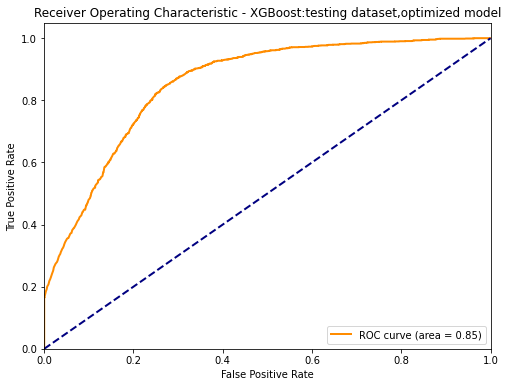

Confusion Matrix:
 [[2777  600]
 [ 554 1166]]


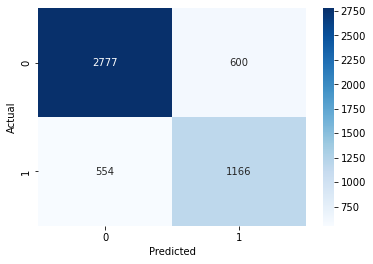

In [61]:
y_pred = xgb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_clf.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset,optimized model')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Classification Report: XGBoosting, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      7942
           1       0.67      0.72      0.70      3950

    accuracy                           0.79     11892
   macro avg       0.76      0.77      0.77     11892
weighted avg       0.79      0.79      0.79     11892



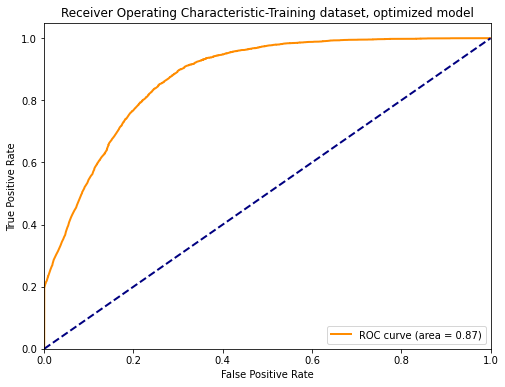

In [62]:
#trouble shooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = xgb_clf.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: XGBoosting, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = xgb_clf.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic-Training dataset, optimized model')
plt.legend(loc="lower right")
plt.show()

### 7. timing of last sequence


In [63]:
var_list=significant_vars['variable'].unique().tolist()+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']

In [64]:
#subset the pancreatic_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in var_list)]
df_last_timing=pancreatic_seq_analysis[sig_cols]

In [65]:
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

In [66]:
#get stats of time between last seqquence and last-event 
df_last_timing['last_seq_to_last_event'].describe()

count    11089.000000
mean       719.045270
std        713.014535
min          0.000000
25%        123.000000
50%        484.000000
75%       1136.000000
max       3066.000000
Name: last_seq_to_last_event, dtype: float64

<Axes: xlabel='last_seq_to_last_event', ylabel='Count'>

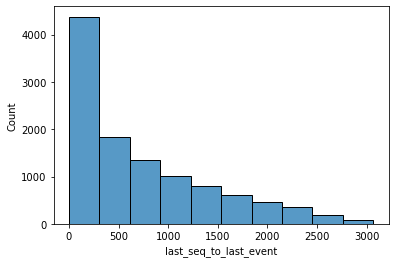

In [67]:
import seaborn as sns
sns.histplot(df_last_timing['last_seq_to_last_event'],bins=10)

In [68]:
pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only.shape

(5670, 29)

In [69]:
pancreatic_only['last_seq_to_last_event'].describe()

count    2607.000000
mean      519.318757
std       555.594848
min         1.000000
25%        86.000000
50%       329.000000
75%       774.000000
max      2775.000000
Name: last_seq_to_last_event, dtype: float64

<Axes: xlabel='last_seq_to_last_event', ylabel='Count'>

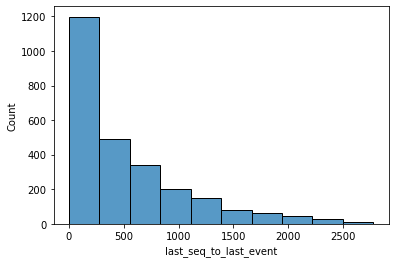

In [89]:
sns.histplot(pancreatic_only['last_seq_to_last_event'],bins=10)

In [90]:
df_all_null = pancreatic_seq_analysis[pancreatic_seq_analysis[end_cols].isna().all(axis=1)]
df_all_null[df_all_null['pancreatic_cancer_dx']==1].shape

(3063, 32)

There are 4006 patients who have none of the 17 sequences.

In [197]:
pancreatic_seq_analysis.shape

(16896, 56)

In [198]:
seq_vars=significant_vars['variable']
test_set=pd.concat([X_test,y_test],axis=1)
mask = (test_set[seq_vars] == 0).all(axis=1)
test_zeros = test_set[mask]
test_zeros.shape

(1555, 20)

There are 1556 patients in the test dataset who have none of the 17 sequences.

### 8 . Model with risk sequence only

In [70]:
xgb_risk=set(xgb_top_features) & set(positive_seq['sequence'].unique())
xgb_risk

{'G89->M54',
 'I12->N18',
 'M25->M54',
 'M25->M79',
 'M54->M79',
 'M79->E87',
 'M79->M25'}

Accuracy: 0.7143417696684324
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.99      0.82      3377
           1       0.88      0.18      0.30      1720

    accuracy                           0.71      5097
   macro avg       0.79      0.58      0.56      5097
weighted avg       0.76      0.71      0.64      5097



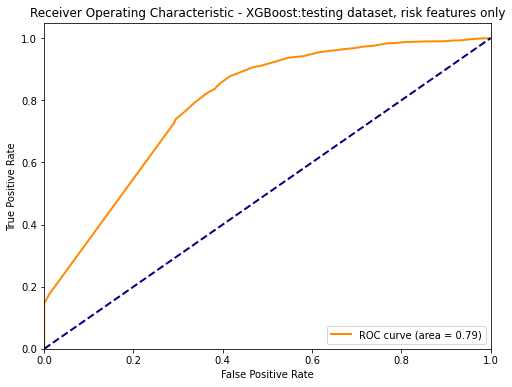

Confusion Matrix:
 [[3336   41]
 [1415  305]]


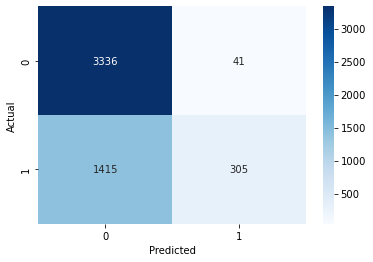

In [72]:
xgb_risk_features=list(xgb_risk)
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train[xgb_risk_features], y_train)

y_pred = xgb_model.predict(X_test[xgb_risk_features])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_model.predict_proba(X_test[xgb_risk_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset, risk features only')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [73]:
var_list=xgb_risk_features+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']
#subset the pancreatic_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in var_list)]
df_last_timing=pancreatic_seq_analysis[sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days
#get stats of time between last seqquence and last-event 
df_last_timing['last_seq_to_last_event'].describe()

count    10645.000000
mean       730.891592
std        717.484740
min          0.000000
25%        128.000000
50%        497.000000
75%       1154.000000
max       3066.000000
Name: last_seq_to_last_event, dtype: float64

In [74]:
pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only.shape

(5670, 26)

In [75]:
pancreatic_only['last_seq_to_last_event'].describe()

count    2574.000000
mean      530.116939
std       562.389699
min         1.000000
25%        90.000000
50%       338.000000
75%       787.750000
max      2775.000000
Name: last_seq_to_last_event, dtype: float64

### 9. Survival analysis

In [199]:
df_survival=df_analysis.copy()
#add in the last_seq_to_last_event
df_survival=df_survival.merge(df_last_timing[['Whio_MemberId','last_seq_to_last_event']],on='Whio_MemberId',how='left')
df_survival.head()

,Whio_MemberId,Age,Sex,last_event_date,E87->J90,J90->J98,E87->J98,E87->J96,E87->D64,A41->E87,...,I50->N18,E87->N18,D72->E87,E11->J98,E87->K76,N18->E87,E11->I50,E11->D64,pancreatic_cancer_dx,last_seq_to_last_event
0,WHIO1000492,73.0,1,2024-03-09,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,NaN
1,WHIO1001631,77.0,0,2023-09-11,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,174.0
2,WHIO1001802,56.0,0,2021-03-08,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,NaN
3,WHIO1001965,62.0,1,2021-01-25,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,NaN
4,WHIO1002083,64.0,0,2019-07-23,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,NaN


#### 8.1. Kaplan meier curves

In [200]:
df_km=df_survival.dropna()

In [201]:
df_km['pancreatic_cancer_dx'].value_counts()

pancreatic_cancer_dx
0    10037
1     1664
Name: count, dtype: int64

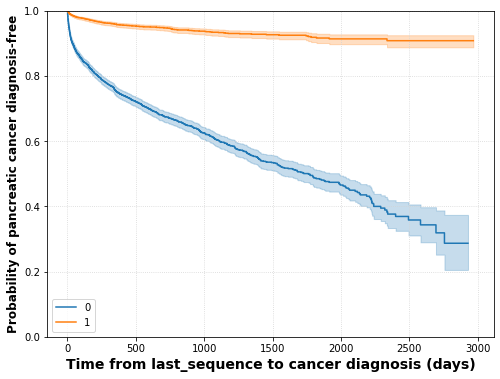

In [202]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
event_col = "pancreatic_cancer_dx"
time_col = "last_seq_to_last_event"

# Create a KaplanMeierFitter object
kmf = KaplanMeierFitter()


groups = df_km['J90->J98'].unique()

kmf_dict = {}
ax = None
plt.figure(figsize=(8, 6))
for g in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(df_km.loc[df_km['J90->J98']==g, time_col],
            event_observed=df_km.loc[df_km['J90->J98']==g, event_col],
            label=g)
    kmf.plot_survival_function(ax=ax, ci_show=True)
    kmf_dict[g] = kmf


# Plot the curves on the same plot

plt.xlabel('Time from last_sequence to cancer diagnosis (days)',fontsize=14,fontweight='bold')
plt.ylabel('Probability of pancreatic cancer diagnosis-free',fontsize=12,fontweight='bold')
plt.ylim(0,1)
# plt.title("Cancer diagnosis probability grouped by whether the patient has sequence J90->J98",fontsize=12,fontweight='bold')
plt.grid(
    True,               # turn on grid
    which='both',       # major & minor ticks (optional)
    linestyle=':',      # dotted lines
    linewidth=0.8,      
    color='lightgrey'   # light grey
)
plt.show()

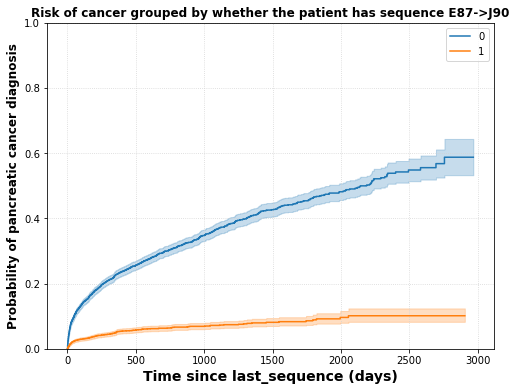

In [203]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Create a KaplanMeierFitter object
kmf = KaplanMeierFitter()

# Suppose you have a DataFrame with:
# durations, events, and a group column (e.g., 'treatment')
groups = df_km['E87->J90'].unique()

kmf_dict = {}
ax = None  # Initialize axis

plt.figure(figsize=(8, 6))

for g in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(df_km.loc[df_km['E87->J90']==g, time_col],
            event_observed=df_km.loc[df_km['E87->J90']==g, event_col],
            label=g)
    
    # CHANGE: Use plot_cumulative_density instead of plot_survival_function
    # This plots (1 - survival), showing the increasing risk of diagnosis
    ax = kmf.plot_cumulative_density(ax=ax, ci_show=True)
    
    kmf_dict[g] = kmf

# Plot formatting
plt.xlabel('Time since last_sequence (days)', fontsize=14, fontweight='bold')
plt.title("Risk of cancer grouped by whether the patient has sequence E87->J90",fontsize=12,fontweight='bold')
# CHANGE: Update Y-label to reflect the "event" probability, 
plt.ylabel('Probability of pancreatic cancer diagnosis', fontsize=12, fontweight='bold')

plt.ylim(0, 1)

plt.grid(
    True,               # turn on grid
    which='both',       # major & minor ticks (optional)
    linestyle=':',      # dotted lines
    linewidth=0.8,      
    color='lightgrey'   # light grey
)

plt.show()

In [204]:
#create a new column "top_2_sequences" based on following conditions

# 1. Define the conditions
conditions = [
    (df_km['J90->J98'] == 1) & (df_km['E87->J90'] == 1), # Both sequences
    (df_km['J90->J98'] == 1),                          # Only has J90->J98
    (df_km['E87->J90'] == 1)                           # Only has E87->J90
]

# 2. Define the values to assign for each condition
# Note: These correspond to the order above
choices = ['have both sequences', 'J90->J98 only', 'E87->J90 only']

# 3. Create the new column using np.select
# 'default' is the value used if none of the conditions are met
df_km['top2_protective sequences'] = np.select(conditions, choices, default='none')

#### 8.2. Random survival forest analysis

In [207]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# The primary library for Random Survival Forest
from sksurv.ensemble import RandomSurvivalForest
# Function to format the target survival variable
from sksurv.util import Surv

# --- 1. Load and Prepare Your Data ---

# Replace 'your_data.csv' and column names with your actual data
# Assuming your DataFrame 'df' contains all features, plus the time and event columns.
df_rsf = df_km.copy()
# Define your time and event columns (e.g., in days/months and 1/0 status)
TIME_COL = 'last_seq_to_last_event' 
EVENT_COL = 'pancreatic_cancer_dx' # 1 for event (e.g., death, recurrence), 0 for censored

# Identify your features (multivariable risk factors)
# Replace with your actual feature column names (e.g., age, tumor_size, pnodes, stage, etc.)
FEATURE_COLS = ['Age', 'Sex', 'E87->J90',
       'J90->J98', 'E87->J98', 'E87->J96', 'E87->D64', 'A41->E87', 'E87->I50',
       'D64->E87', 'I50->E87', 'I50->N18', 'E87->N18', 'D72->E87', 'E11->J98',
       'E87->K76', 'N18->E87', 'E11->I50', 'E11->D64',] 
X = df_rsf[FEATURE_COLS]

# Handle categorical variables (must be converted to numeric/one-hot encoded)
X = pd.get_dummies(X, drop_first=True) # Example: One-hot encode any remaining non-numeric columns

# Create the structured array for the survival outcome (Time and Event)
y = Surv.from_arrays(
    event=df_rsf[EVENT_COL].astype(bool),  # Must be boolean (True/False)
    time=df_rsf[TIME_COL]
)

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [208]:
# --- 2. Initialize and Train the Random Survival Forest ---

rsf = RandomSurvivalForest(
    n_estimators=1000,          # Number of trees in the forest (increase for better performance)
    min_samples_split=10,       # Minimum number of samples required to split an internal node
    min_samples_leaf=15,        # Minimum number of samples required to be at a leaf node
    max_features="sqrt",        # Number of features to consider when looking for the best split
    n_jobs=-1,                  # Use all available CPU cores for parallel training
    random_state=42
)

# Fit the model to the training data
rsf.fit(X_train, y_train)

print("RSF Model Training Complete.")

RSF Model Training Complete.


In [209]:
# --- 3. Prediction and Evaluation ---

# Import the C-index metric
from sksurv.metrics import concordance_index_ipcw

# Evaluate the model on the test set
c_index = concordance_index_ipcw(y_train, y_test, rsf.predict(X_test))[0]

print(f"Test Set Concordance Index (C-index): {c_index:.3f}")

Test Set Concordance Index (C-index): 0.899


In [210]:
%%time
from sklearn.inspection import permutation_importance

# --- 1. Calculate Permutation Importance ---

# NOTE: We use the C-index (Concordance Index) as the scoring metric
# The Permutation Importance calculates how much the C-index drops 
# when a feature's values are randomly shuffled.

# Calculate importance on the test set for a realistic assessment
perm_importance = permutation_importance(
    rsf,                 # Your trained RandomSurvivalForest model
    X_test,              # Test feature data (X_test)
    y_test,              # Test survival data (y_test)
    n_repeats=10,        # Number of times to shuffle the feature (more = better estimate)
    random_state=42,
    n_jobs=-1            # Use all available cores
)

CPU times: total: 20min 29s
Wall time: 1h 5min 46s



--- Permutation Feature Importance (Top 5 Risk Factors) ---
J90->J98    0.104290
E87->J90    0.094603
I50->E87    0.022954
E87->I50    0.018137
D64->E87    0.015399
dtype: float64


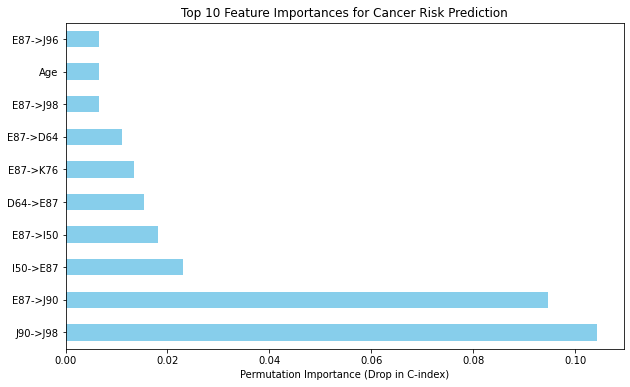

In [211]:
# --- 2. Process and Plot the Results ---

# The importance scores are in the 'importances_mean' attribute of the result
importance_mean = perm_importance.importances_mean

# Create a Series for easy sorting and visualization
feature_importance = pd.Series(importance_mean, index=X_test.columns)

# Sort the results to see the most important features first
# IMPORTANT: The scores are the *drop* in C-index, so higher is better/more important
sorted_importance = feature_importance.sort_values(ascending=True) # Ascending here keeps largest values at the bottom of the bar chart for better visualization

print("\n--- Permutation Feature Importance (Top 5 Risk Factors) ---")
print(sorted_importance.tail(5).sort_values(ascending=False)) # Display top 5 descending

# Plotting the importance results
plt.figure(figsize=(10, 6))
# Plot the top 10 features
sorted_importance.tail(10).plot(kind='barh', color='skyblue') 
plt.xlabel("Permutation Importance (Drop in C-index)")
plt.title("Top 10 Feature Importances for Cancer Risk Prediction")
plt.gca().invert_yaxis() # Invert to have the most important feature at the top
plt.show()

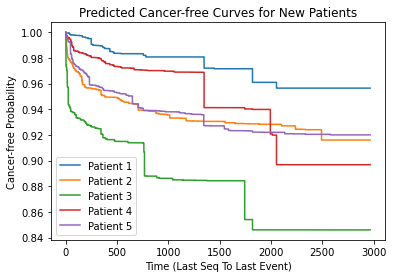

In [220]:
# Assuming 'survival_functions' is the NumPy array of StepFunction objects
# And 'time_points' is the 1D array of time values (shape 1923,)
# Note: The time points are embedded in the StepFunction's 'x' array, but
# using your external 'time_points' is generally safer for a clean plot.

for i, s_func in enumerate(survival_functions):
    # 1. CALL the StepFunction object with your time_points array.
    #    This returns the survival probability array (y-values) for that patient.
    s_array = s_func(time_points)

    # 2. Plot the resulting 1D array of probabilities (s_array) against time_points.
    #    time_points and s_array will now both have shape (1923,).
    plt.step(time_points, s_array, where="post", label=f"Patient {i+1}")

plt.title("Predicted Cancer-free Curves for New Patients")
plt.xlabel(f"Time ({TIME_COL.replace('_', ' ').title()})")
plt.ylabel("Cancer-free Probability") # Added Y-axis label for completeness
plt.legend()
plt.show() # Make sure you call plt.show() if not in a notebook environment